# MASTER'S THESIS


## Data Analysis

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

In [55]:
#load the data

##For willet catalog

# For K2_APG_BHM
data_path = '../data/willet_catalog/'
df_willet = pd.read_csv(data_path + 'cat_K2_GAL_BHM.csv')
df_columns = df_willet.columns

df_rel_data_dnu = df_willet[df_willet['RelDat_Dnu'] == True]
df_rel_data_l = df_willet[df_willet['RelDat_L'] == True]

df_rel_age_dnu = df_willet[df_willet['RelAge_Dnu'] == True]
df_rel_age_l = df_willet[df_willet['RelAge_L'] == True]

df_intersection = df_willet[(df_willet["RelDat_Dnu"] == True) & (df_willet["RelDat_L"] == True)]

print(len(df_rel_data_dnu))
print(len(df_rel_data_l))
print(len(df_rel_age_dnu))
print(len(df_rel_age_l))

5266
5056
4486
5041


/tmp/ipykernel_31968/2582250263.py:7: DtypeWarning: Columns (64) have mixed types. Specify dtype option on import or set low_memory=False.
  df_willet = pd.read_csv(data_path + 'cat_K2_GAL_BHM.csv')


### Examine how different is Rel_Data constained by L and real data constrain by Dnu

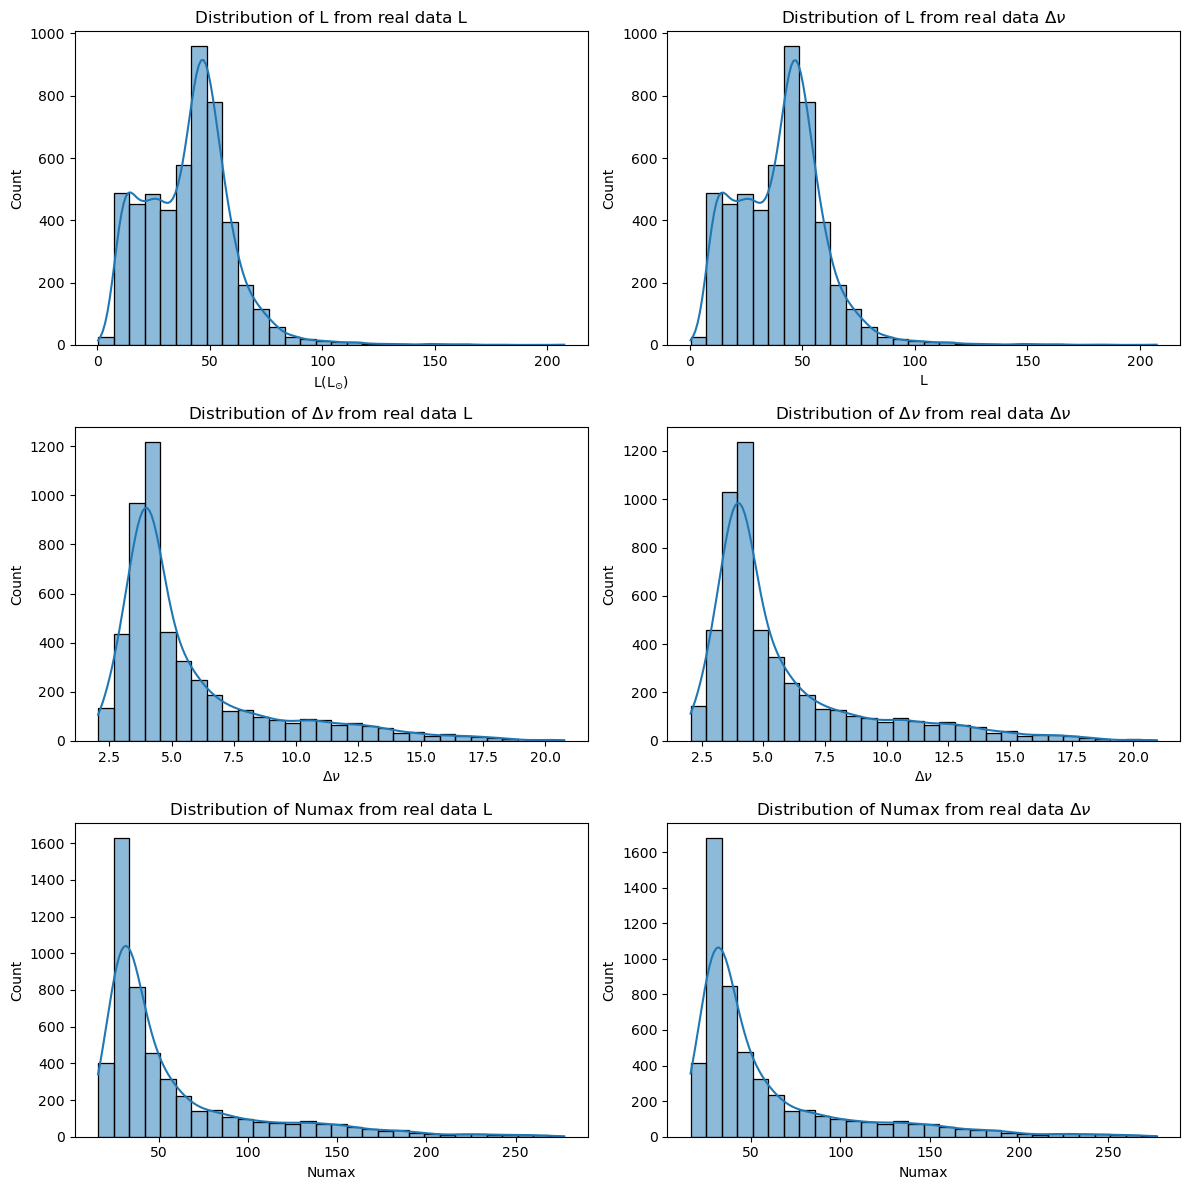

In [56]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# --- Row 0: L ---
sns.histplot(
    data=df_rel_data_l,
    x='L',
    bins=30,
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Distribution of L from real data L')
axes[0, 0].set_xlabel('L(L$_{\\odot}$)')
axes[0, 0].set_ylabel('Count')

sns.histplot(
    data=df_rel_data_dnu,
    x='L',
    bins=30,
    kde=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title(r'Distribution of L from real data $\Delta\nu$')
axes[0, 1].set_xlabel('L')
axes[0, 1].set_ylabel('Count')

# --- Row 1: Delta nu ---
sns.histplot(
    data=df_rel_data_l,
    x='Dnu',
    bins=30,
    kde=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title(r'Distribution of $\Delta\nu$ from real data L')
axes[1, 0].set_xlabel(r'$\Delta\nu$')
axes[1, 0].set_ylabel('Count')

sns.histplot(
    data=df_rel_data_dnu,
    x='Dnu',
    bins=30,
    kde=True,
    ax=axes[1, 1]
)
axes[1, 1].set_title(r'Distribution of $\Delta\nu$ from real data $\Delta\nu$')
axes[1, 1].set_xlabel(r'$\Delta\nu$')
axes[1, 1].set_ylabel('Count')

# --- Row 2: Numax ---
sns.histplot(
    data=df_rel_data_l,
    x='numax',
    bins=30,
    kde=True,
    ax=axes[2, 0]
)
axes[2, 0].set_title(r'Distribution of Numax from real data L')
axes[2, 0].set_xlabel(r'Numax')
axes[2, 0].set_ylabel('Count')

sns.histplot(
    data=df_rel_data_dnu,
    x='numax',
    bins=30,
    kde=True,
    ax=axes[2, 1]
)
axes[2, 1].set_title(r'Distribution of Numax from real data $\Delta\nu$')
axes[2, 1].set_xlabel(r'Numax')
axes[2, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Examining If makes sense mass_Dnu or age_dnu from L constrained data and viceversa

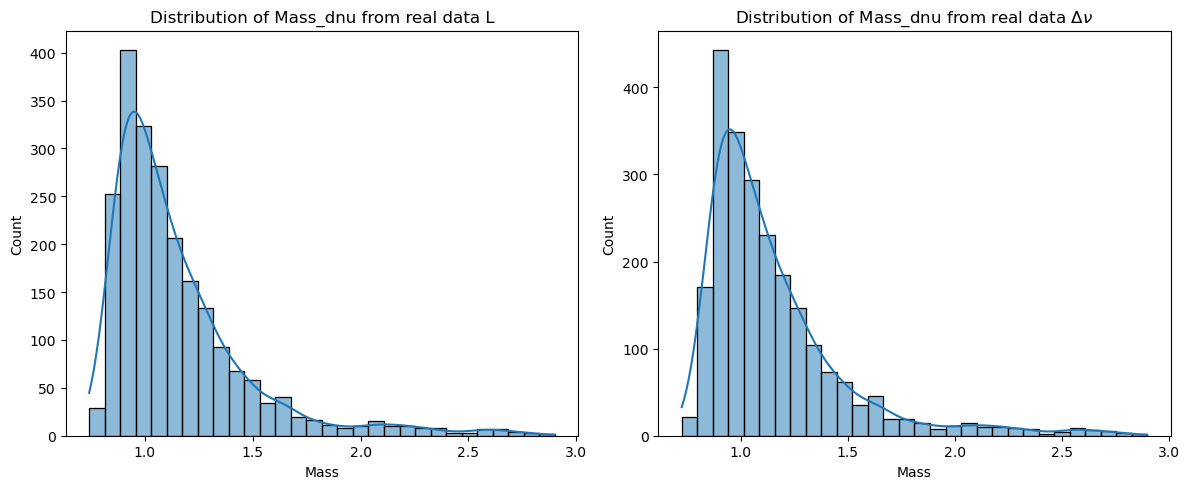

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    data=df_rel_data_l,
    x='mass_Dnu',
    bins=30,
    kde=True,
    ax=axes[0]
)
axes[0].set_title(r'Distribution of Mass_dnu from real data L')
axes[0].set_xlabel(r'Mass')
axes[0].set_ylabel('Count')

sns.histplot(
    data=df_rel_data_dnu,
    x='mass_Dnu',
    bins=30,
    kde=True,
    ax=axes[1]
)
axes[1].set_title(r'Distribution of Mass_dnu from real data $\Delta\nu$')
axes[1].set_xlabel(r'Mass')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Okey there is a small difference still probably better to use Mass_dnu age_dnu only from the dnu constrained data

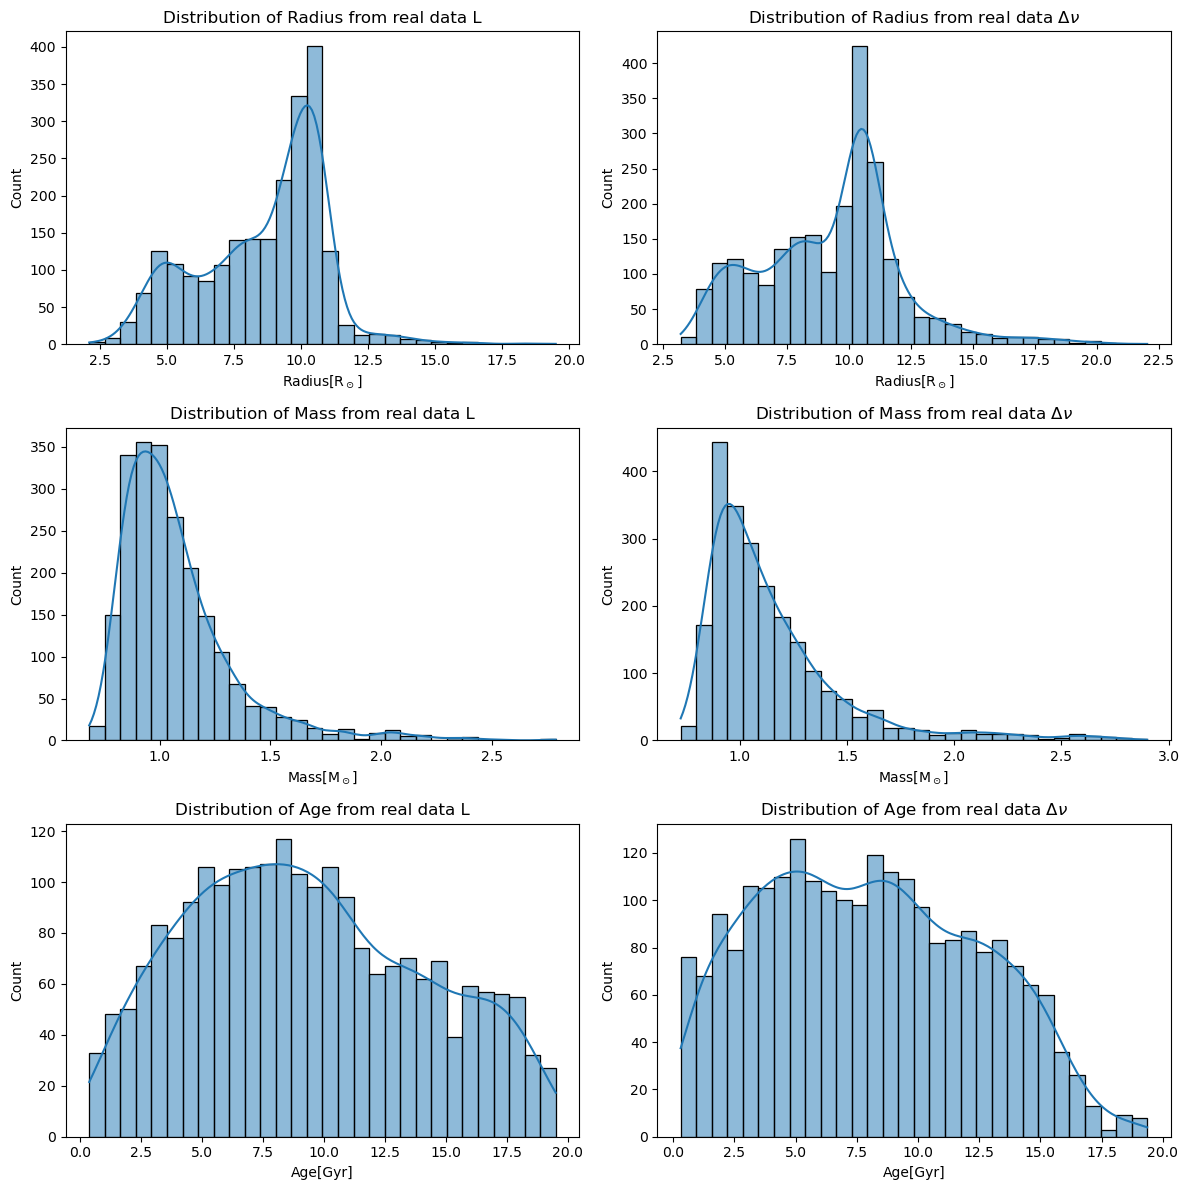

In [58]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# --- Row 0: Radius ---
sns.histplot(
    data=df_rel_data_l,
    x='rad_L',
    bins=30,
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title(r'Distribution of Radius from real data L')
axes[0, 0].set_xlabel(r'Radius[R$_\odot$]')
axes[0, 0].set_ylabel('Count')

sns.histplot(
    data=df_rel_data_dnu,
    x='rad_Dnu',
    bins=30,
    kde=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title(r'Distribution of Radius from real data $\Delta\nu$')
axes[0, 1].set_xlabel(r'Radius[R$_\odot$]')
axes[0, 1].set_ylabel('Count')

# --- Row 1: Mass ---
sns.histplot(
    data=df_rel_data_l,
    x='mass_L',
    bins=30,
    kde=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title(r'Distribution of Mass from real data L')
axes[1, 0].set_xlabel(r'Mass[M$_\odot$]')
axes[1, 0].set_ylabel('Count')

sns.histplot(
    data=df_rel_data_dnu,
    x='mass_Dnu',
    bins=30,
    kde=True,
    ax=axes[1, 1]
)
axes[1, 1].set_title(r'Distribution of Mass from real data $\Delta\nu$')
axes[1, 1].set_xlabel(r'Mass[M$_\odot$]')
axes[1, 1].set_ylabel('Count')

# --- Row 2: Age ---
sns.histplot(
    data=df_rel_data_l,
    x='age_L',
    bins=30,
    kde=True,
    ax=axes[2, 0]
)
axes[2, 0].set_title(r'Distribution of Age from real data L')
axes[2, 0].set_xlabel(r'Age[Gyr]')
axes[2, 0].set_ylabel('Count')

sns.histplot(
    data=df_rel_data_dnu,
    x='age_Dnu',
    bins=30,
    kde=True,
    ax=axes[2, 1]
)
axes[2, 1].set_title(r'Distribution of Age from real data $\Delta\nu$')
axes[2, 1].set_xlabel(r'Age[Gyr]')
axes[2, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Okey, looks like they are pretty compatible, maybe too much, just to check ¿are they the same?

In [59]:
common_ids = set(df_rel_data_l['K2_ID']) & set(df_rel_data_dnu['K2_ID'])

print(f"df_rel_data_l rows: {len(df_rel_data_l)}")
print(f"df_rel_data_dnu rows: {len(df_rel_data_dnu)}")
print(f"Common K2_IDs: {len(common_ids)}")
print(f"Only in df_rel_data_l: {len(set(df_rel_data_l['K2_ID']) - set(df_rel_data_dnu['K2_ID']))}")
print(f"Only in df_rel_data_dnu: {len(set(df_rel_data_dnu['K2_ID']) - set(df_rel_data_l['K2_ID']))}")

same_dataset = (
    len(df_rel_data_l) == len(df_rel_data_dnu)
    and set(df_rel_data_l['K2_ID']) == set(df_rel_data_dnu['K2_ID'])
)

print(f"Same dataset: {same_dataset}")

df_rel_data_l rows: 5056
df_rel_data_dnu rows: 5266
Common K2_IDs: 5056
Only in df_rel_data_l: 0
Only in df_rel_data_dnu: 210
Same dataset: False


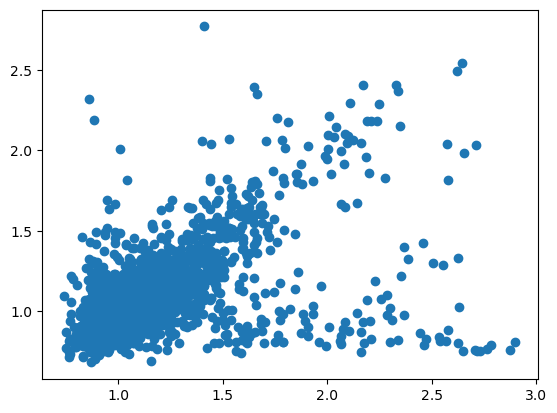

In [61]:
plt.scatter(df_intersection["mass_Dnu"], df_intersection["mass_L"])